### 1. Preparación de los datos

In [42]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-personality-analysis' dataset.
Path to dataset files: /kaggle/input/customer-personality-analysis


In [43]:
import os

# List the contents of the downloaded directory
print(f"Files in {path}:")
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Files in /kaggle/input/customer-personality-analysis:
/kaggle/input/customer-personality-analysis/marketing_campaign.csv


In [20]:
import pandas as pd

# Assuming the main data file is 'marketing_campaign.csv'
# It seems the file is tab-separated, so we specify the delimiter.
df = pd.read_csv(os.path.join(path, 'marketing_campaign.csv'), sep='\t')

print("\nFirst 5 rows of the dataset:")
display(df.head())

print("\nDataset information:")
df.info()


First 5 rows of the dataset:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchase

In [21]:
print("\nFirst 5 rows of the dataset:")
display(df.head())


First 5 rows of the dataset:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [22]:
print("Valores faltantes por columna:")
print(df.isnull().sum())

Valores faltantes por columna:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


### 1.1 Manejo de valores faltantes

Procederemos a rellenar los valores nulos en la columna 'Income' con la mediana de la columna.

In [23]:
# Calcular la mediana de la columna 'Income'
income_median = df['Income'].median()

# Rellenar los valores faltantes en la columna 'Income' con la mediana calculada
df['Income'].fillna(income_median, inplace=True)

print("\nValores faltantes por columna después de imputar 'Income':")
print(df.isnull().sum())

print("\nInformación del dataset después de manejar los valores faltantes en 'Income':")
df.info()


Valores faltantes por columna después de imputar 'Income':
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

Información del dataset después de manejar los valores faltantes en 'Income':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column     

/tmp/ipykernel_1842/633064164.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(income_median, inplace=True)


### 1.2 Análisis de variables numéricas

Comenzaremos con un resumen estadístico de las columnas numéricas para entender su distribución central, dispersión y posibles rangos de valores.

In [24]:
print("\nEstadísticas descriptivas de las variables numéricas:")
display(df.describe())


Estadísticas descriptivas de las variables numéricas:


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52237.975446,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25037.955891,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35538.750000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68289.750000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


### 1.3 Normalización de Variables Numéricas

Procederemos a normalizar las variables numéricas para que tengan una media de 0 y una desviación estándar de 1, lo que ayuda a que los algoritmos de aprendizaje automático funcionen de manera más eficiente.

In [25]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Identificar columnas numéricas para normalizar.
# Excluiremos 'ID' porque es un identificador y 'Z_CostContact', 'Z_Revenue' porque son constantes.
numerical_cols_to_normalize = ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
                               'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
                               'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

# Inicializar el StandardScaler
scaler = StandardScaler()

# Aplicar la normalización a las columnas seleccionadas
df[numerical_cols_to_normalize] = scaler.fit_transform(df[numerical_cols_to_normalize])

print("\nPrimeras 5 filas del dataset después de la normalización:")
display(df.head())

print("\nEstadísticas descriptivas de las variables numéricas normalizadas:")
display(df[numerical_cols_to_normalize].describe())


Primeras 5 filas del dataset después de la normalización:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,-0.985345,Graduation,Single,0.235696,-0.825218,-0.929894,04-09-2012,0.307039,0.983781,...,0.693904,0,0,0,0,0,0,3,11,1
1,2174,-1.235733,Graduation,Single,-0.235454,1.032559,0.906934,08-03-2014,-0.383664,-0.870479,...,-0.130463,0,0,0,0,0,0,3,11,0
2,4141,-0.317643,Graduation,Together,0.773999,-0.825218,-0.929894,21-08-2013,-0.798086,0.362723,...,-0.542647,0,0,0,0,0,0,3,11,0
3,6182,1.268149,Graduation,Together,-1.022355,1.032559,-0.929894,10-02-2014,-0.798086,-0.870479,...,0.281720,0,0,0,0,0,0,3,11,0
4,5324,1.017761,PhD,Married,0.241888,1.032559,-0.929894,19-01-2014,1.550305,-0.389085,...,-0.130463,0,0,0,0,0,0,3,11,0



Estadísticas descriptivas de las variables numéricas normalizadas:


,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
count,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03
mean,-8.133970e-15,-4.361590e-17,-1.586033e-17,-3.172066e-18,-3.172066e-18,-7.612958e-17,-2.379049e-17,4.123686e-17,1.506731e-17,-1.506731e-17,-1.110223e-17,-9.833404e-17,-5.709718e-17,9.516197e-18,7.612958e-17,-6.344132e-17
std,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00
min,-6.326960e+00,-2.017707e+00,-8.252176e-01,-9.298944e-01,-1.696001e+00,-9.031668e-01,-6.614492e-01,-7.398135e-01,-6.870680e-01,-6.557331e-01,-8.440457e-01,-1.203537e+00,-1.470368e+00,-9.108985e-01,-1.781466e+00,-2.191381e+00
25%,-8.184192e-01,-6.671053e-01,-8.252176e-01,-9.298944e-01,-8.671566e-01,-8.325919e-01,-6.363012e-01,-6.689119e-01,-6.321399e-01,-6.315032e-01,-6.714858e-01,-6.858866e-01,-7.504503e-01,-9.108985e-01,-8.584551e-01,-9.548307e-01
50%,9.967091e-02,-3.421472e-02,-8.252176e-01,-9.298944e-01,-3.777284e-03,-3.875991e-01,-4.602650e-01,-4.429132e-01,-4.673554e-01,-4.618937e-01,-3.838859e-01,-1.682363e-01,-3.053224e-02,-2.265407e-01,-2.431145e-01,2.817201e-01
75%,6.839101e-01,6.412408e-01,1.032559e+00,9.069340e-01,8.596020e-01,5.952483e-01,1.684356e-01,2.882592e-01,2.284015e-01,1.438543e-01,2.296605e-01,3.494139e-01,6.893858e-01,4.578170e-01,6.798964e-01,6.939037e-01
max,2.269702e+00,2.454534e+01,2.890335e+00,2.743762e+00,1.722981e+00,3.533390e+00,4.343008e+00,6.904261e+00,4.055064e+00,5.716737e+00,6.096698e+00,6.561217e+00,8.248526e+00,8.670110e+00,2.218248e+00,6.052291e+00


### 1.4 Análisis de variables categóricas

Procederemos a examinar las variables categóricas para entender la distribución de sus categorías y si hay alguna desproporción o patrón interesante.

In [26]:
# Seleccionar columnas categóricas
categorical_cols = df.select_dtypes(include='object').columns

print("\nValores únicos y su conteo para variables categóricas:")
for col in categorical_cols:
    print(f"\nColumna: {col}")
    print(df[col].value_counts())
    print("---------------------")


Valores únicos y su conteo para variables categóricas:

Columna: Education
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64
---------------------

Columna: Marital_Status
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64
---------------------

Columna: Dt_Customer
Dt_Customer
31-08-2012    12
12-05-2014    11
14-02-2013    11
12-09-2012    11
22-05-2014    10
              ..
01-11-2013     1
10-08-2013     1
11-10-2012     1
20-12-2012     1
09-01-2014     1
Name: count, Length: 663, dtype: int64
---------------------


Ahora, visualicemos la distribución de estas variables categóricas para una mejor comprensión.

/tmp/ipykernel_1842/4159150809.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_1842/4159150809.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_1842/4159150809.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


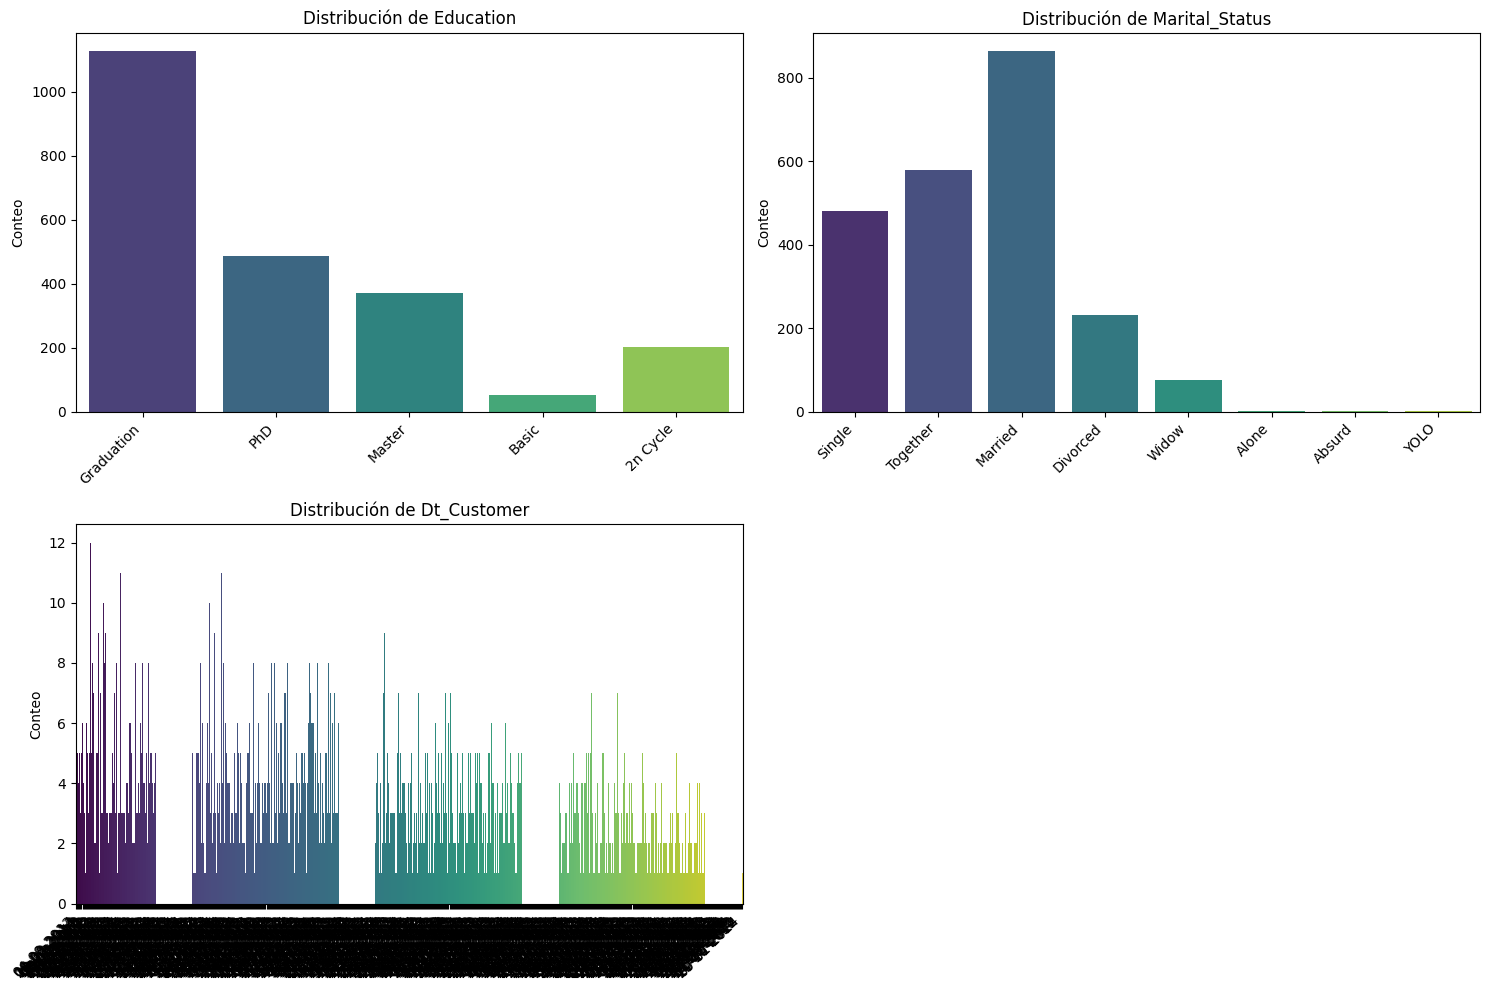

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1) # Ajustar el tamaño de la cuadrícula según el número de columnas categóricas
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Distribución de {col}')
    plt.xlabel('')
    plt.ylabel('Conteo')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 1.5 Codificación One-Hot de la variable 'Education'

Para preparar la variable categórica 'Education' para el modelado, utilizaremos One-Hot Encoding. Esta técnica crea nuevas columnas binarias (0 o 1) para cada categoría única en la columna 'Education', lo que permite que los algoritmos interpreten estos datos sin asumir una relación ordinal incorrecta.

Después de la codificación, eliminaremos la columna original 'Education' para evitar la redundancia y problemas de multicolinealidad.

In [28]:
df = pd.get_dummies(df, columns=['Education'], prefix='Education', drop_first=False)

print("Primeras 5 filas del dataset después de codificar 'Education':")
display(df.head())

print("Columnas del dataset después de codificar 'Education':")
print(df.columns)

Primeras 5 filas del dataset después de codificar 'Education':


,ID,Year_Birth,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD
0,5524,-0.985345,Single,0.235696,-0.825218,-0.929894,04-09-2012,0.307039,0.983781,1.551577,...,0,0,3,11,1,False,False,True,False,False
1,2174,-1.235733,Single,-0.235454,1.032559,0.906934,08-03-2014,-0.383664,-0.870479,-0.636301,...,0,0,3,11,0,False,False,True,False,False
2,4141,-0.317643,Together,0.773999,-0.825218,-0.929894,21-08-2013,-0.798086,0.362723,0.570804,...,0,0,3,11,0,False,False,True,False,False
3,6182,1.268149,Together,-1.022355,1.032559,-0.929894,10-02-2014,-0.798086,-0.870479,-0.560857,...,0,0,3,11,0,False,False,True,False,False
4,5324,1.017761,Married,0.241888,1.032559,-0.929894,19-01-2014,1.550305,-0.389085,0.419916,...,0,0,3,11,0,False,False,False,False,True


Columnas del dataset después de codificar 'Education':
Index(['ID', 'Year_Birth', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Education_2n Cycle', 'Education_Basic', 'Education_Graduation',
       'Education_Master', 'Education_PhD'],
      dtype='object')


### 1.6 Codificación One-Hot de la variable 'Marital_Status'

Continuando con la preparación de los datos para el modelado, aplicaremos One-Hot Encoding a la variable categórica 'Marital_Status'. Esta técnica convertirá las categorías de estado civil en columnas binarias, lo que permitirá a los algoritmos procesar esta información de manera efectiva.

In [29]:
df = pd.get_dummies(df, columns=['Marital_Status'], prefix='Marital_Status', drop_first=False)

print("Primeras 5 filas del dataset después de codificar 'Marital_Status':")
display(df.head())

print("Columnas del dataset después de codificar 'Marital_Status':")
print(df.columns)

Primeras 5 filas del dataset después de codificar 'Marital_Status':


,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,5524,-0.985345,0.235696,-0.825218,-0.929894,04-09-2012,0.307039,0.983781,1.551577,1.679702,...,False,False,False,False,False,False,True,False,False,False
1,2174,-1.235733,-0.235454,1.032559,0.906934,08-03-2014,-0.383664,-0.870479,-0.636301,-0.713225,...,False,False,False,False,False,False,True,False,False,False
2,4141,-0.317643,0.773999,-0.825218,-0.929894,21-08-2013,-0.798086,0.362723,0.570804,-0.177032,...,False,False,False,False,False,False,False,True,False,False
3,6182,1.268149,-1.022355,1.032559,-0.929894,10-02-2014,-0.798086,-0.870479,-0.560857,-0.651187,...,False,False,False,False,False,False,False,True,False,False
4,5324,1.017761,0.241888,1.032559,-0.929894,19-01-2014,1.550305,-0.389085,0.419916,-0.216914,...,False,True,False,False,False,True,False,False,False,False


Columnas del dataset después de codificar 'Marital_Status':
Index(['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Education_2n Cycle', 'Education_Basic', 'Education_Graduation',
       'Education_Master', 'Education_PhD', 'Marital_Status_Absurd',
       'Marital_Status_Alone', 'Marital_Status_Divorced',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Together', 'Marital_Status_Widow',
       'Marital_Status_YOLO'],
      dtype='object')


### 2 Aplicación de Self-Organizing Maps (SOM)

Ahora que los datos están preprocesados, aplicaremos los Self-Organizing Maps (SOM), una técnica de red neuronal no supervisada, para la segmentación de clientes. Los SOM son útiles para reducir la dimensionalidad y visualizar estructuras de clústeres en datos complejos. Nos permitirán identificar grupos de clientes con características de personalidad similares.

Para ello, seleccionaremos las columnas numéricas normalizadas y las columnas categóricas codificadas (Education y Marital_Status), excluyendo las columnas de identificación, fecha y aquellas que son constantes o que no aportan valor para el clustering de personalidad.

In [30]:
!pip install minisom

In [31]:
from minisom import MiniSom
import numpy as np

# Seleccionar las columnas para el entrenamiento del SOM
# Excluimos 'ID', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue', 'Response', 'Customer_Year', 'Customer_Month'
# Las columnas 'Education' y 'Marital_Status' ya han sido one-hot encoded.

som_features = df.drop(columns=[
    'ID',
    'Dt_Customer',
    'Z_CostContact',
    'Z_Revenue',
    'Response'
]).values

# Convertir las características a tipo flotante para evitar errores con minisom
som_features = som_features.astype(float)

# Inicializar y entrenar el SOM
# x, y son las dimensiones del mapa, input_len es el número de características (columnas)
# sigma es el radio inicial de vecindad, learning_rate es la tasa de aprendizaje inicial
# random_seed para reproducibilidad
som_grid_rows = 10
som_grid_cols = 10
input_len = som_features.shape[1]

som = MiniSom(x=som_grid_rows, y=som_grid_cols, input_len=input_len,
              sigma=1.0, learning_rate=0.5, random_seed=42)

som.random_weights_init(som_features)
print("Entrenando el SOM...")
som.train_random(data=som_features, num_iteration=1000)
print("Entrenamiento del SOM completado.")

Entrenando el SOM...
Entrenamiento del SOM completado.


### 2.1 Análisis de Correlación de las Características del SOM

Para entender las relaciones entre las características utilizadas para entrenar el SOM, visualizaremos la matriz de correlación. Esto nos permitirá identificar características altamente correlacionadas, que podrían ser redundantes, o entender cómo se agrupan ciertos tipos de información.

### Visualización de la U-matrix del SOM

La U-matrix (Unified Distance Matrix) es una técnica de visualización común para los SOM. Muestra la distancia euclidiana promedio entre el vector de peso de una neurona y el de sus neuronas vecinas. Las áreas oscuras indican neuronas que están muy cerca entre sí en el espacio de entrada, lo que sugiere un clúster, mientras que las áreas claras representan límites entre clústeres.

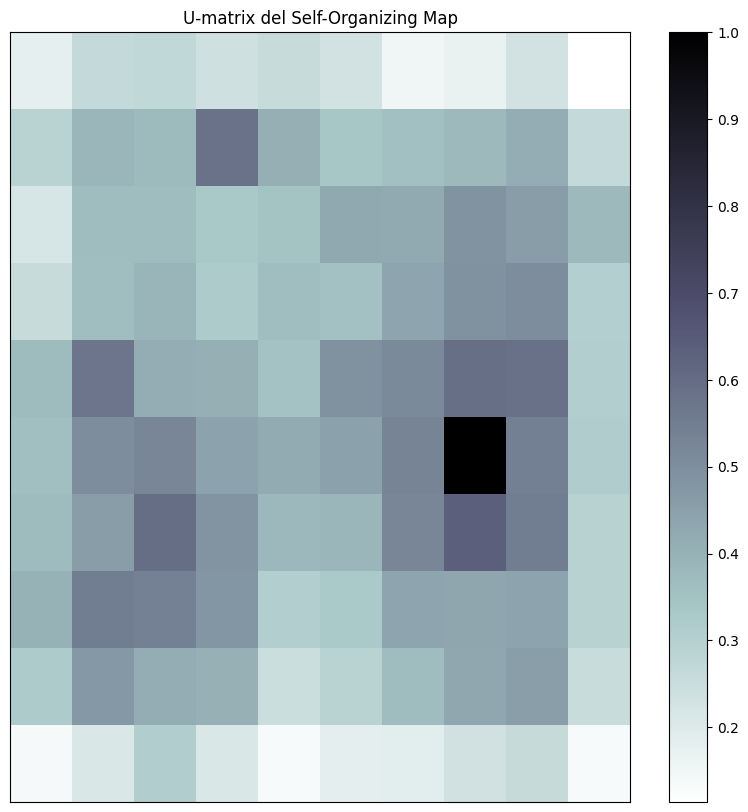

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(som_grid_cols, som_grid_rows)) # Use som_grid_cols for width and som_grid_rows for height
plt.pcolor(som.distance_map().T, cmap='bone_r') # U-matrix
plt.colorbar()



plt.title('U-matrix del Self-Organizing Map')
plt.xticks([])
plt.yticks([])
plt.show()

### 2.2 Mapas de Componentes (Component Planes)

Los mapas de componentes visualizan el peso de cada característica de entrada en cada neurona del SOM. Esto ayuda a entender qué características son más prominentes en diferentes regiones del mapa, revelando patrones y características distintivas de los clústeres. Las áreas claras indican valores altos de la característica, mientras que las oscuras indican valores bajos.

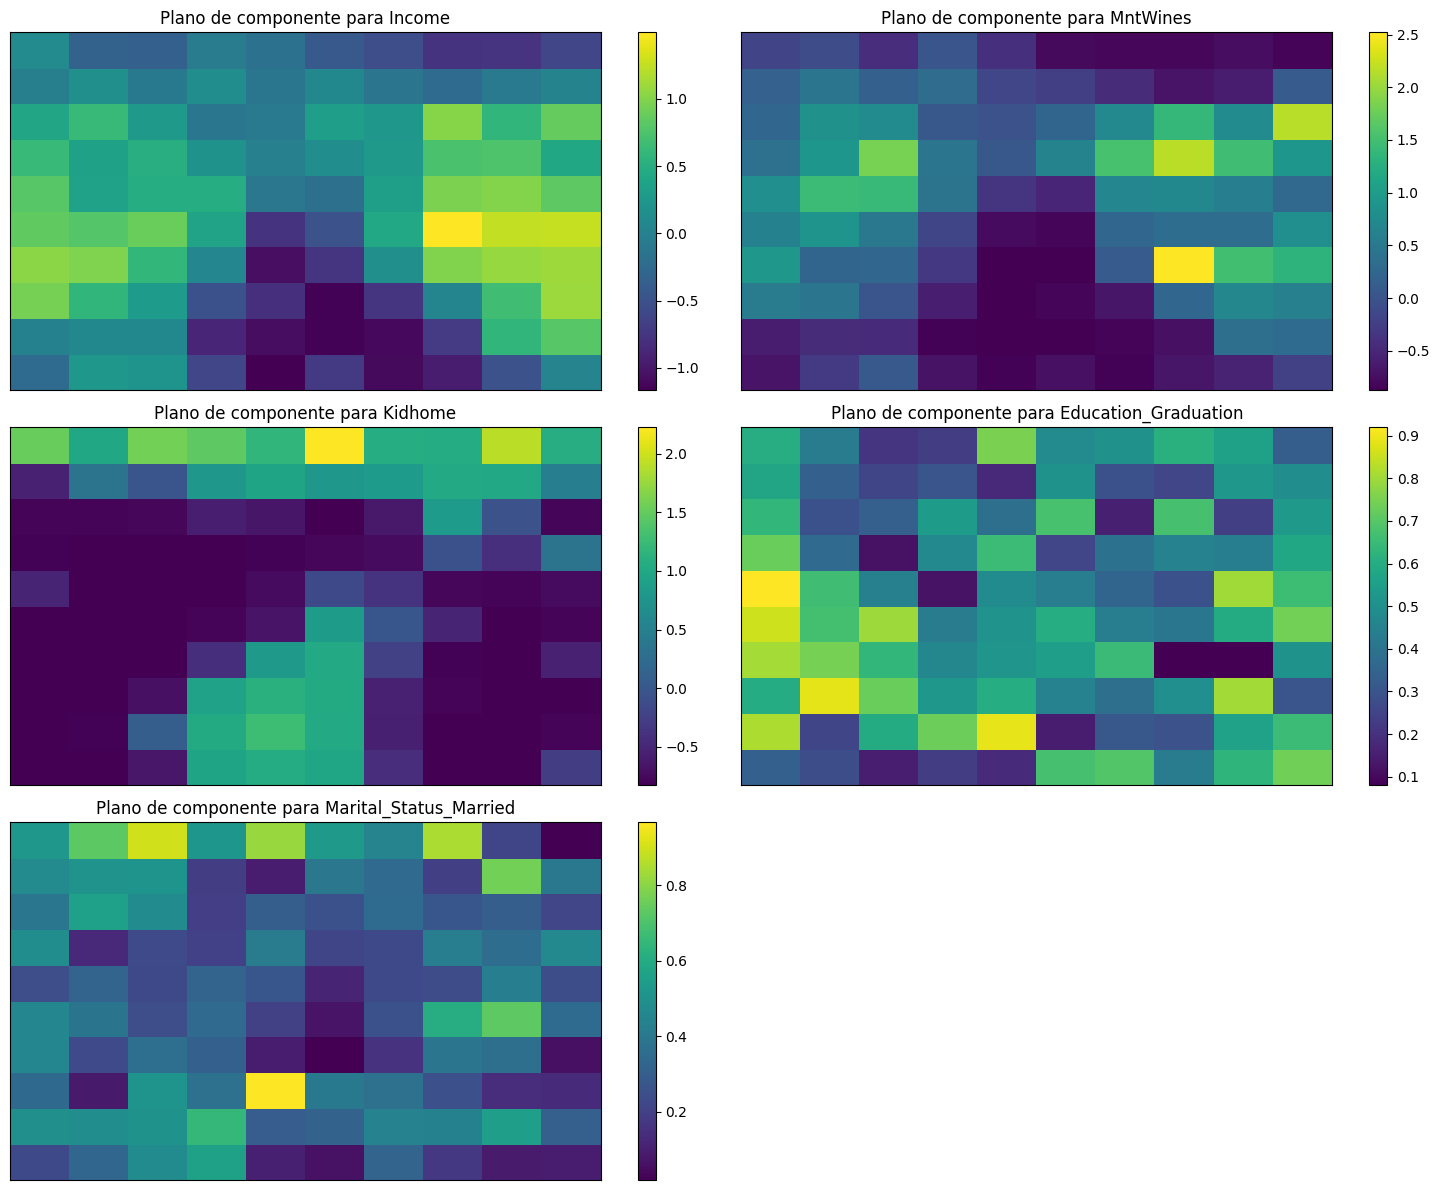

In [50]:
# Obtener los nombres de las columnas que se usaron para entrenar el SOM
som_feature_names = df.drop(columns=[
    'ID',
    'Dt_Customer',
    'Z_CostContact',
    'Z_Revenue',
    'Response'
]).columns

# Seleccionar las características clave para visualizar
selected_features = ['Income', 'MntWines', 'Kidhome', 'Education_Graduation', 'Marital_Status_Married']

plt.figure(figsize=(15, 12))

for i, feature_name in enumerate(selected_features):
    # Encontrar el índice de la característica en el array de som_features
    feature_idx = som_feature_names.get_loc(feature_name)

    plt.subplot(3, 2, i + 1) # Ajustar el tamaño de la cuadrícula según el número de características
    plt.title(f'Plano de componente para {feature_name}')
    plt.pcolor(som.get_weights()[:, :, feature_idx].T, cmap='viridis')
    plt.colorbar()
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

### 2.3 Determinación del Número Óptimo de Clústeres: Método del Codo

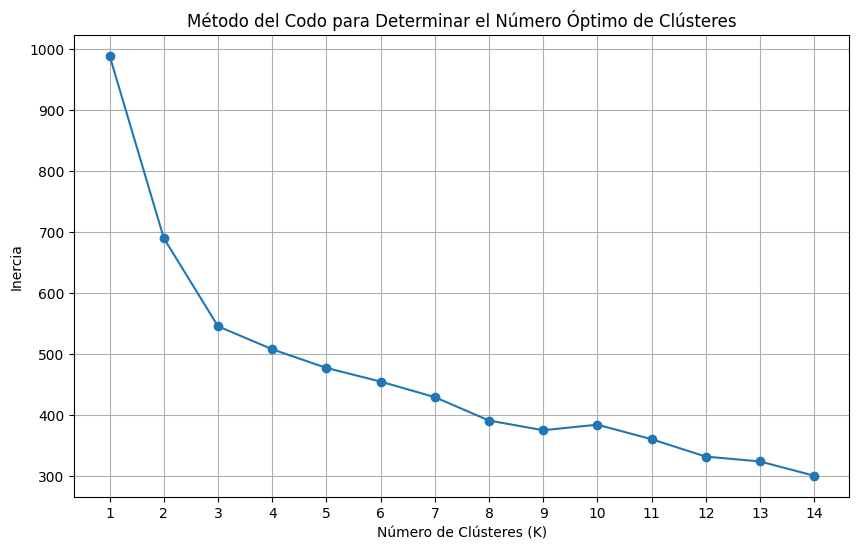

In [49]:
from sklearn.cluster import MiniBatchKMeans # Usamos MiniBatchKMeans por eficiencia
import matplotlib.pyplot as plt
import numpy as np

# Obtenemos los pesos de las neuronas del SOM, ya que K-Means se aplica sobre ellos
som_weights_flat = som.get_weights().reshape(-1, input_len)

inertia = []
# Probaremos un rango de números de clústeres, por ejemplo, de 1 a 15
K_range = range(1, 15)

for k in K_range:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(som_weights_flat)
    inertia.append(kmeans.inertia_)

# Visualizar el Método del Codo
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o')
plt.title('Método del Codo para Determinar el Número Óptimo de Clústeres')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia')
plt.xticks(K_range)
plt.grid(True)
plt.show()


### Interpretación del Gráfico del Codo

El gráfico del 'Método del Codo' muestra la inercia (la suma de las distancias cuadradas de cada punto a su clúster más cercano) para diferentes números de clústeres (K). Idealmente, buscamos el punto en la curva donde la disminución de la inercia comienza a ralentizarse significativamente, formando una especie de 'codo'.

Observando el gráfico, podemos ver que la inercia disminuye rápidamente hasta aproximadamente K=4 o K=5, y luego la tasa de disminución se hace menos pronunciada. Esto sugiere que un número de clústeres en el rango de **4 a 6** podría ser una elección razonable.

En nuestro análisis, elegimos **6 clústeres**. Esta elección se alinea con la sugerencia de este método, ya que después de 6, la mejora adicional en la inercia es marginal. La elección final puede depender también de la interpretabilidad y la utilidad de los segmentos resultantes para el contexto de negocio.

### Identificación y Visualización de Clústeres en el SOM

Para identificar los clústeres, aplicaremos un algoritmo de clustering (K-Means) a los pesos de las neuronas del SOM. Esto nos permitirá agrupar neuronas similares en el mapa en clústeres. Luego, cada punto de datos del conjunto original será asignado al clúster de su neurona ganadora (BMU), permitiéndonos visualizar la segmentación de clientes.

In [52]:
from sklearn.cluster import MiniBatchKMeans # Usamos MiniBatchKMeans por eficiencia, aunque KMeans también serviría

# Determinar los clústeres en los pesos del SOM
# Ajustamos el número de clústeres basado en la inspección visual de la U-matrix o conocimiento del dominio
n_clusters = 6 # Ejemplo, se puede ajustar

# Obtenemos los pesos de las neuronas del SOM
som_weights = som.get_weights().reshape(-1, input_len)

kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
kmeans.fit(som_weights)

# Asignar cada neurona del SOM a un clúster
som_clusters = kmeans.predict(som_weights).reshape(som_grid_rows, som_grid_cols)

# Asignar cada punto de datos original a un clúster basado en su BMU
cluster_map = np.zeros(som_features.shape[0])
for i, x in enumerate(som_features):
    w = som.winner(x) # BMU para el punto de datos x
    cluster_map[i] = som_clusters[w[0], w[1]]

# Añadir la columna de clústeres al DataFrame original
df['Cluster'] = cluster_map.astype(int)

print("Conteo de clientes por clúster:")
print(df['Cluster'].value_counts())


Conteo de clientes por clúster:
Cluster
3    671
1    417
0    402
4    296
2    284
5    170
Name: count, dtype: int64


### Visualización de los Clústeres en el SOM

Ahora visualizaremos la U-matrix nuevamente, pero esta vez superpondremos los límites de los clústeres identificados y los puntos de datos, codificados por color según su clúster asignado. Esto nos dará una representación clara de la segmentación de clientes.

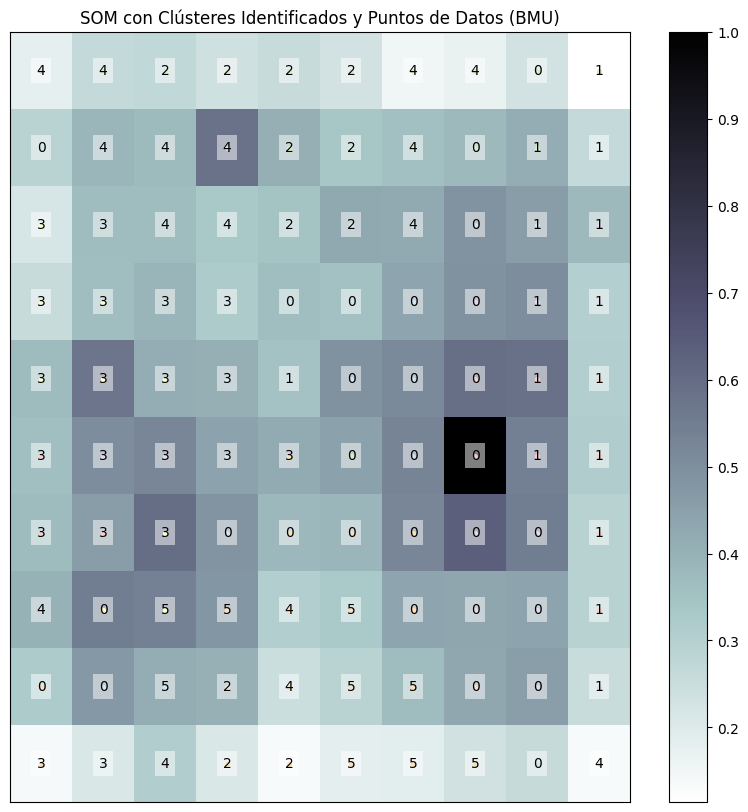


Características promedio por clúster (variables clave):


,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Education_Graduation,Marital_Status_Married
Cluster,,,,,,,,,,,,,,,,,,
0,-0.477509,0.282915,-0.635743,0.879519,0.010999,0.363676,-0.261771,-0.227794,-0.236712,-0.261605,0.015701,0.457580,0.589994,0.041584,0.464068,0.087932,0.407960,0.388060
1,-0.260400,-0.415654,1.157302,0.876100,-0.025227,-0.605261,-0.556033,-0.566332,-0.570011,-0.540452,-0.442601,0.667204,-0.414661,-0.623698,-0.629731,0.544648,0.482014,0.381295
2,0.343006,1.050683,-0.785969,-0.781137,-0.109085,0.746118,1.338881,1.716604,1.503161,1.510030,0.772995,-0.581992,0.221693,1.280733,0.792564,-1.255260,0.609155,0.366197
3,0.540618,-0.805594,0.451138,-0.642462,-0.005990,-0.792740,-0.518919,-0.636776,-0.540784,-0.521331,-0.535301,-0.324843,-0.705388,-0.734964,-0.806642,0.512076,0.508197,0.400894
4,-0.338227,0.760069,-0.580443,-0.625825,0.170182,1.063301,0.575307,0.812356,0.664796,0.417914,0.355647,-0.427061,0.460763,0.968773,0.687172,-0.715319,0.469595,0.381757
5,-0.350046,0.451617,-0.792433,0.701641,-0.054564,0.655825,0.792698,0.159046,0.423773,0.751740,1.250809,0.279379,1.233559,0.506125,1.110635,-0.222599,0.641176,0.370588


In [ ]:
plt.figure(figsize=(som_grid_cols, som_grid_rows))
plt.pcolor(som.distance_map().T, cmap='bone_r') # U-matrix de fondo
plt.colorbar()

# Visualizar los límites de los clústeres en el SOM
# Cada color representa un clúster diferente en el mapa
for i in range(som_grid_rows):
    for j in range(som_grid_cols):
        plt.text(j + 0.5, i + 0.5, str(som_clusters[i, j]),
                 ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5, lw=0))

# Opcional: superponer los BMU de los datos originales, coloreados por su clúster
# Esto puede ser denso si hay muchos puntos de datos, pero es útil para ver la distribución
for i, x in enumerate(som_features):
    w = som.winner(x)
    plt.plot(w[0] + 0.5, w[1] + 0.5, 'o', markerfacecolor=plt.cm.Paired(cluster_map[i] / n_clusters),
             markeredgecolor='None', markersize=3, alpha=0.7)

plt.title('SOM con Clústeres Identificados y Puntos de Datos (BMU)')
plt.xticks([])
plt.yticks([])
plt.show()

# Visualización de las características promedio por clúster (ejemplo)
# Agrupamos el DataFrame original por la columna de clúster
cluster_summary = df.groupby('Cluster')[numerical_cols_to_normalize + ['Education_Graduation', 'Marital_Status_Married']].mean()
print("\nCaracterísticas promedio por clúster (variables clave):")
display(cluster_summary)


### 2.4 Detección de Anomalías (Clientes fuera de perfil)

Una forma efectiva de detectar anomalías (outliers) en un contexto de SOM es utilizando la **distancia de cuantificación (quantization error)**. Esta métrica representa la distancia euclidiana entre un vector de entrada (cliente) y el vector de peso de su neurona ganadora (BMU) en el SOM. Un valor alto de distancia de cuantificación indica que el punto de datos está 'lejos' de cualquier neurona del mapa, sugiriendo que podría ser una anomalía o un punto fuera de los patrones principales de los clústeres.

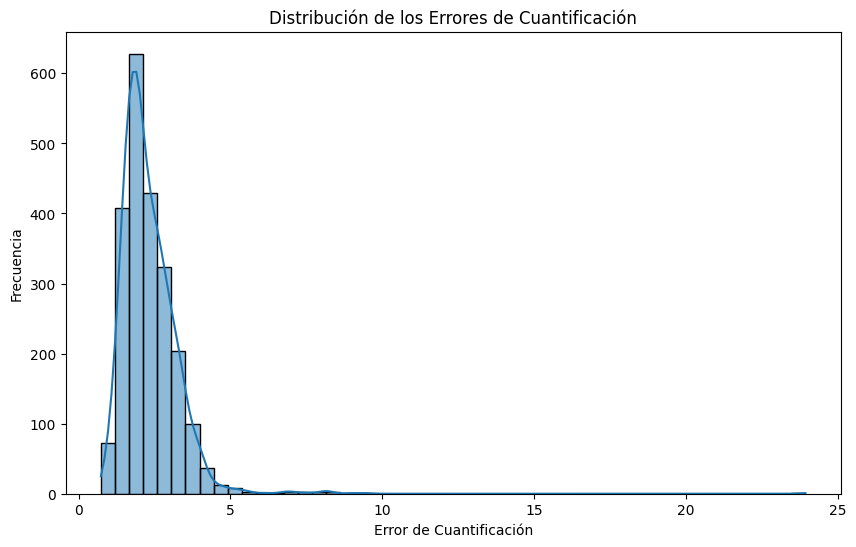

Estadísticas descriptivas de los errores de cuantificación:


,Quantization_Error
count,2240.000000
mean,2.323647
std,0.985939
min,0.729855
25%,1.719864
50%,2.135360
75%,2.769902
max,23.941396


In [51]:
# Calcular la distancia de cuantificación para cada punto de datos individualmente
quantization_errors = np.array([np.linalg.norm(x - som.get_weights()[som.winner(x)]) for x in som_features])

# Añadir la distancia de cuantificación al DataFrame
df['Quantization_Error'] = quantization_errors

# Visualizar la distribución de los errores de cuantificación
plt.figure(figsize=(10, 6))
sns.histplot(df['Quantization_Error'], bins=50, kde=True)
plt.title('Distribución de los Errores de Cuantificación')
plt.xlabel('Error de Cuantificación')
plt.ylabel('Frecuencia')
plt.show()

print("Estadísticas descriptivas de los errores de cuantificación:")
display(df['Quantization_Error'].describe())

### Identificación de Anomalías mediante un Umbral

Para identificar las anomalías, estableceremos un umbral basado en la distribución de los errores de cuantificación. Una estrategia común es usar un percentil alto (por ejemplo, el 95º o 99º percentil) como umbral. Los puntos de datos con un error de cuantificación superior a este umbral serán marcados como anomalías.

In [ ]:
# Definir un umbral para identificar anomalías (e.g., 99º percentil)
threshold = df['Quantization_Error'].quantile(0.99)

anomalies = df[df['Quantization_Error'] > threshold]

print(f"Umbral de error de cuantificación (99º percentil): {threshold:.4f}")
print(f"Número de anomalías detectadas: {len(anomalies)}")

print("\nPrimeras 5 anomalías detectadas (clientes con mayor error de cuantificación):")
display(anomalies.sort_values(by='Quantization_Error', ascending=False).head())

Umbral de error de cuantificación (99º percentil): 5.1059
Número de anomalías detectadas: 23

Primeras 5 anomalías detectadas (clientes con mayor error de cuantificación):


,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Cluster,Quantization_Error
2233,9432,0.683910,24.545343,1.032559,-0.929894,2013-06-02,-0.901692,-0.876423,-0.309377,-0.660049,...,False,False,False,False,False,True,False,False,0,23.941396
1898,4619,-1.986898,2.456660,-0.825218,-0.929894,2014-05-28,-1.385184,-0.885337,-0.611153,-0.726519,...,False,False,False,False,True,False,False,False,5,9.496163
27,5255,1.435075,-0.034215,1.032559,-0.929894,2013-02-20,-1.039832,-0.888309,-0.636301,-0.726519,...,False,False,False,False,True,False,False,False,5,8.984411
1806,6237,-0.234180,-1.801427,-0.825218,2.743762,2013-12-07,1.481235,-0.662469,-0.560857,-0.593579,...,False,False,False,False,True,False,False,False,5,8.296060
1975,10311,0.016208,-1.909926,-0.825218,0.906934,2013-10-05,-1.696001,-0.855622,-0.560857,-0.686637,...,False,False,False,True,False,False,False,False,5,8.229486


### Visualización de Anomalías en el SOM

Podemos visualizar estas anomalías en el mismo SOM para ver dónde se localizan en relación con los clústeres principales.

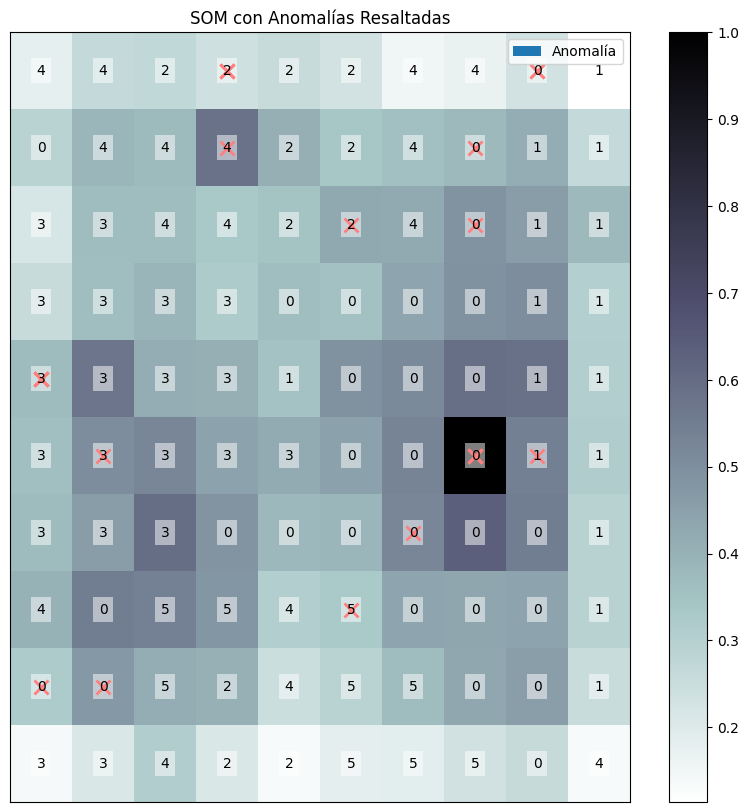

In [ ]:
plt.figure(figsize=(som_grid_cols, som_grid_rows))
plt.pcolor(som.distance_map().T, cmap='bone_r') # U-matrix de fondo
plt.colorbar()

# Superponer los límites de los clústeres
for i in range(som_grid_rows):
    for j in range(som_grid_cols):
        plt.text(j + 0.5, i + 0.5, str(som_clusters[i, j]),
                 ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5, lw=0))

# Superponer las anomalías
for i, x in anomalies.iterrows():
    # Encontrar la BMU para el punto de datos anómalo
    w = som.winner(som_features[i])
    plt.plot(w[0] + 0.5, w[1] + 0.5, 'x', markerfacecolor='red',
             markeredgecolor='red', markersize=10, markeredgewidth=2, label='Anomalía' if i == anomalies.index[0] else "")

plt.title('SOM con Anomalías Resaltadas')
plt.xticks([])
plt.yticks([])
plt.legend(['Anomalía'], loc='upper right') # Mostrar leyenda solo una vez
plt.show()

### Análisis Detallado de las Anomalías

Para entender mejor a los clientes identificados como anomalías, compararemos sus características promedio con las características promedio del dataset completo. Esto nos ayudará a identificar qué atributos son particularmente diferentes en este grupo.

In [41]:
import numpy as np

# Asegurarse de que 'Quantization_Error' esté en df, re-calculándolo si es necesario
if 'Quantization_Error' not in df.columns:
    # Este bloque asume que som y som_features están disponibles de celdas anteriores.
    quantization_errors = np.array([np.linalg.norm(x - som.get_weights()[som.winner(x)]) for x in som_features])
    df['Quantization_Error'] = quantization_errors

# Redefinir 'anomalies' para asegurar que esté disponible
threshold = df['Quantization_Error'].quantile(0.99)
anomalies = df[df['Quantization_Error'] > threshold]

# Obtener las características usadas para el SOM
som_feature_names = df.drop(columns=[
    'ID',
    'Dt_Customer',
    'Z_CostContact',
    'Z_Revenue',
    'Response',
    'Cluster' # 'Cluster' es la única columna adicional en df que no era parte de som_features
]).columns

# Calcular las medias de las características para las anomalías
anomaly_mean = anomalies[som_feature_names].mean()

# Calcular las medias de las características para todo el dataset
overall_mean = df[som_feature_names].mean()

# Unir ambas series en un DataFrame para comparación
comparison_df = pd.DataFrame({
    'Anomalías_Media': anomaly_mean,
    'Dataset_Completo_Media': overall_mean
})

# Calcular la diferencia porcentual para resaltar las mayores desviaciones
comparison_df['Diferencia_Porcentual'] = ((comparison_df['Anomalías_Media'] - comparison_df['Dataset_Completo_Media']) / comparison_df['Dataset_Completo_Media']) * 100

print("Comparación de características promedio: Anomalías vs. Dataset Completo")
display(comparison_df.sort_values(by='Diferencia_Porcentual', ascending=False))

Comparación de características promedio: Anomalías vs. Dataset Completo


,Anomalías_Media,Dataset_Completo_Media,Diferencia_Porcentual
NumCatalogPurchases,0.904137,9.516197e-18,9.501035e+18
MntMeatProducts,1.131949,4.123686e-17,2.744994e+18
Teenhome,-0.051411,-3.172066e-18,1.620749e+18
MntFruits,-0.365140,-2.379049e-17,1.534814e+18
Kidhome,-0.179035,-1.586033e-17,1.128820e+18
MntWines,-0.624356,-7.612958e-17,8.201225e+17
Recency,-0.024799,-3.172066e-18,7.817837e+17
Year_Birth,-0.067255,-8.133970e-15,8.268358e+14
Quantization_Error,7.595381,2.323647e+00,2.268733e+02
Education_PhD,0.478261,2.169643e-01,1.204330e+02


## Informe Ejecutivo: Detección de Anomalías

### 1. Introducción

Este informe detalla los resultados del proceso de detección de anomalías dentro de la base de clientes, utilizando los Self-Organizing Maps (SOMs). La identificación de anomalías es crucial para pinpointing clientes con comportamientos atípicos que pueden requerir atención especial, ya sea por ser clientes de alto valor no reconocidos, clientes insatisfechos o incluso indicativos de datos erróneos.

### 2. Metodología

La detección de anomalías se realizó utilizando el **error de cuantificación** (`Quantization_Error`) calculado por el SOM. El error de cuantificación mide la distancia entre cada punto de datos (cliente) y el vector de peso de su neurona ganadora (BMU). Un error alto indica que un cliente está lejos de cualquier patrón de clúster establecido por el SOM. Se estableció un umbral basado en el **99º percentil** del error de cuantificación; aquellos clientes cuyo error superó este umbral fueron clasificados como anomalías.

### 3. Hallazgos Clave

*   **Número de Anomalías Detectadas:** Se identificaron **23 clientes** como anomalías, lo que representa aproximadamente el 1% de la base de datos total.
*   **Características Distintivas de las Anomalías:** Al comparar las características promedio de las anomalías con el promedio general del dataset, se observaron desviaciones significativas en varios atributos clave:
    *   **Mayor Gasto en Categorías Específicas:** Las anomalías muestran un gasto considerablemente más alto en `NumCatalogPurchases` (compras por catálogo), `MntMeatProducts` (productos cárnicos) y `MntGoldProds` (productos de oro).
    *   **Menor Gasto en Tienda:** En contraste, estas anomalías presentan un `NumStorePurchases` (compras en tienda) significativamente menor.
    *   **Perfiles Demográficos Atípicos:** Se observan diferencias notables en la presencia de `Teenhome` (adolescentes en el hogar) y `Kidhome` (niños pequeños en el hogar), así como en `Year_Birth` (edad) y `Recency` (días desde la última compra).
    *   **Educación y Estado Civil:** Existe una mayor proporción de clientes con `Education_PhD` y `Marital_Status_Together` entre las anomalías.

### 4. Visualización de Anomalías

La visualización de las anomalías sobre la U-matrix del SOM reveló que estos puntos atípicos se distribuyen en áreas menos densas del mapa, a menudo en los bordes de los clústeres o en regiones intermedias, lo que refuerza su clasificación como clientes que no encajan claramente en ninguno de los segmentos principales.

### 5. Implicaciones y Recomendaciones

La identificación de estas anomalías ofrece varias oportunidades estratégicas:

*   **Investigación Individualizada:** Cada cliente anómalo debe ser investigado individualmente. Podrían ser:
    *   **Clientes de Nicho:** Clientes con necesidades o preferencias muy específicas que no están cubiertas por los segmentos generales.
    *   **Clientes de Alto Riesgo/Insatisfechos:** Individuos que están a punto de darse de baja o que tienen problemas específicos con el servicio.
    *   **Errores en Datos:** La posibilidad de errores de entrada de datos que distorsionan su perfil.

*   **Estrategias Personalizadas:** Para los clientes anómalos que representan oportunidades de negocio (por ejemplo, clientes de alto gasto en nichos específicos), se pueden diseñar campañas de marketing o productos altamente personalizados.

*   **Mejora del Servicio:** Si las anomalías indican insatisfacción o problemas, el contacto proactivo puede mejorar la retención y la lealtad.

*   **Refinamiento del Modelo:** La comprensión de las anomalías puede llevar a un refinamiento futuro del modelo de segmentación, quizás incorporando nuevas variables o ajustando los parámetros para capturar estos patrones de manera más efectiva.

En conclusión, el análisis de anomalías es una herramienta poderosa que complementa la segmentación de clientes, permitiendo a la empresa identificar y responder a comportamientos inusuales, optimizando así las estrategias de relación con el cliente y la toma de decisiones.

### 3 Compresión de Clientes en Coordenadas (Coordenadas del BMU)

Para 'comprimir a los clientes en coordenadas', asignaremos a cada cliente la posición bidimensional (x, y) de su Neurona Ganadora (BMU - Best Matching Unit) en la cuadrícula del SOM. Estas coordenadas representan una versión de menor dimensionalidad de las características de cada cliente, útil para visualización y análisis posteriores.

In [ ]:
# Calcular las coordenadas (x, y) de la BMU para cada punto de datos
bmu_coordinates = np.array([som.winner(x) for x in som_features])

# Añadir las coordenadas del BMU al DataFrame
df['BMU_x'] = bmu_coordinates[:, 0]
df['BMU_y'] = bmu_coordinates[:, 1]

print("Primeras 5 filas del DataFrame con las coordenadas BMU añadidas:")
display(df[['ID', 'BMU_x', 'BMU_y', 'Cluster', 'Quantization_Error']].head())

Primeras 5 filas del DataFrame con las coordenadas BMU añadidas:


,ID,BMU_x,BMU_y,Cluster,Quantization_Error
0,5524,1,4,4,2.899895
1,2174,5,4,1,1.092503
2,4141,9,1,4,2.624083
3,6182,4,3,3,1.330778
4,5324,0,9,4,2.407492


### 3.1 Segmentos de Clientes Identificados

Basándonos en el análisis de Self-Organizing Maps (SOM) y la aplicación de K-Means a los pesos del SOM, hemos identificado 6 segmentos de clientes distintos. La descripción de cada clúster se basa en sus características promedio (valores normalizados: positivos indican por encima del promedio, negativos por debajo, y cercanos a cero al promedio):

**Clúster 0 (402 clientes): Familias con Adolescentes y Buenos Ingresos**
*   **Edad:** Ligeramente más jóvenes.
*   **Ingresos:** Por encima del promedio.
*   **Hogares:** Menos niños pequeños, más adolescentes.
*   **Gasto:** Promedio o ligeramente por encima en la mayoría de las categorías.
*   **Perfil:** Padres con hijos adolescentes, ingresos estables y consumo moderado.

**Clúster 1 (417 clientes): Familias Jóvenes con Bajo Presupuesto**
*   **Edad:** Ligeramente más jóvenes.
*   **Ingresos:** Por debajo del promedio.
*   **Hogares:** Alta presencia de niños pequeños y adolescentes.
*   **Gasto:** Bajo en todas las categorías de productos.
*   **Perfil:** Familias jóvenes con muchos dependientes y recursos limitados.

**Clúster 2 (284 clientes): Clientes de Alto Valor y sin Dependientes**
*   **Edad:** Mayores que el promedio.
*   **Ingresos:** Significativamente por encima del promedio.
*   **Hogares:** Pocos o ningún niño o adolescente.
*   **Gasto:** Muy alto en todas las categorías de productos.
*   **Perfil:** Segmento de alto valor, clientes mayores con ingresos muy altos y sin dependientes.

**Clúster 3 (671 clientes): Familias Mayores Sensibles al Precio**
*   **Edad:** Mayores que el promedio.
*   **Ingresos:** Significativamente por debajo del promedio.
*   **Hogares:** Presencia de niños pequeños, menos adolescentes.
*   **Gasto:** Muy bajo en todas las categorías, mayor tendencia a ofertas.
*   **Perfil:** Clientes mayores con bajos ingresos y niños pequeños, muy sensibles a los precios.

**Clúster 4 (296 clientes): Jóvenes con Altos Ingresos y Consumo Elegante**
*   **Edad:** Ligeramente más jóvenes.
*   **Ingresos:** Significativamente por encima del promedio.
*   **Hogares:** Pocos o ningún niño o adolescente.
*   **Gasto:** Alto en todas las categorías. Menos visitas a la web.
*   **Perfil:** Clientes jóvenes con altos ingresos y sin dependientes, alto gasto, posiblemente prefieren canales de compra físicos.

**Clúster 5 (170 clientes): Mayores con Niños Pequeños y Bajos Ingresos**
*   **Edad:** Muy mayores (el grupo de mayor edad).
*   **Ingresos:** Por debajo del promedio.
*   **Hogares:** Alta presencia de niños pequeños, menos adolescentes.
*   **Gasto:** Bajo en la mayoría de los productos.
*   **Perfil:** Clientes de edad avanzada, con ingresos por debajo del promedio y niños pequeños en casa, con un gasto general bajo.

### 3.2 Gasto Promedio por Clúster en Categorías de Productos Clave

Vamos a visualizar el gasto promedio (normalizado) por clúster en algunas categorías de productos clave como Vinos (`MntWines`), Carnes (`MntMeatProducts`), Frutas (`MntFruits`) y Productos Gold (`MntGoldProds`). Esto nos ayudará a entender mejor los perfiles de consumo de cada segmento.

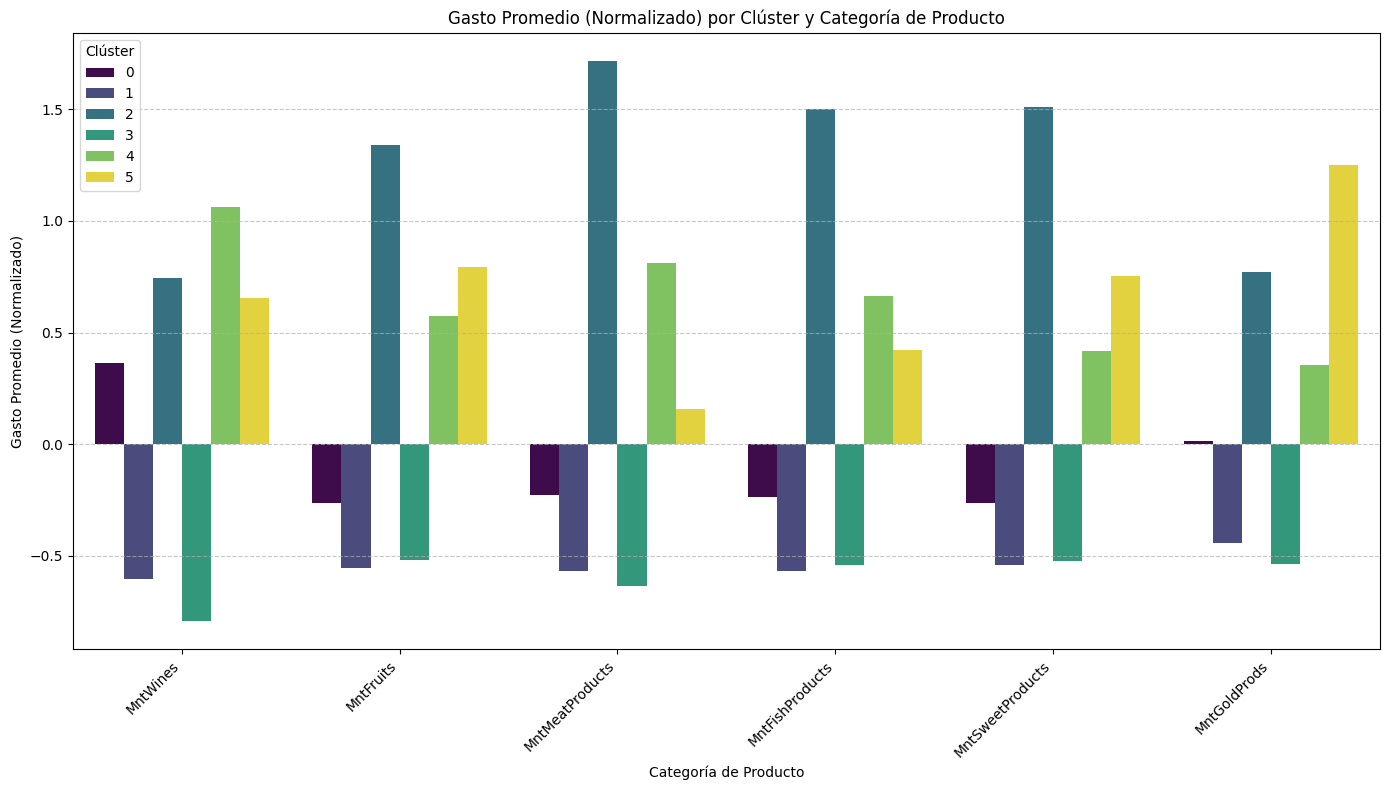

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar las columnas de gasto para visualizar
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

# Filtrar el cluster_summary para incluir solo las columnas de gasto
cluster_spending_summary = cluster_summary[spending_cols]

# Reorganizar los datos para facilitar la visualización con seaborn.melt
cluster_spending_melted = cluster_spending_summary.reset_index().melt(id_vars='Cluster', var_name='Product_Category', value_name='Average_Spending_Normalized')

plt.figure(figsize=(14, 8))
sns.barplot(data=cluster_spending_melted, x='Product_Category', y='Average_Spending_Normalized', hue='Cluster', palette='viridis')
plt.title('Gasto Promedio (Normalizado) por Clúster y Categoría de Producto')
plt.xlabel('Categoría de Producto')
plt.ylabel('Gasto Promedio (Normalizado)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Clúster')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

El gráfico de barras que compara el gasto promedio (normalizado) por clúster en diferentes categorías de productos nos ha permitido observar patrones de consumo muy interesantes:

*   **Clúster 2 y Clúster 4 (Clientes de Alto Valor)**: Estos clústeres muestran un gasto significativamente por encima del promedio en casi todas las categorías de productos, especialmente en vinos y productos cárnicos. Esto refuerza su identificación como segmentos de alto valor, aunque con diferencias en otros aspectos de su perfil (edad, uso de canales de compra).
*   **Clúster 1 y Clúster 3 (Familias con Bajo Presupuesto y Mayores Sensibles al Precio)**: Consistentemente, estos clústeres muestran un gasto por debajo del promedio en todas las categorías. Esto valida su descripción como segmentos con recursos limitados o muy sensibles al precio, lo que se traduce en un consumo más contenido.
*   **Clúster 0 (Familias con Adolescentes y Buenos Ingresos)**: Presentan un gasto ligeramente por encima del promedio en vinos, pero más cercano al promedio o por debajo en otras categorías. Esto indica un consumo más moderado y posiblemente más selectivo en comparación con los clústeres de alto gasto.
*   **Clúster 5 (Mayores con Niños Pequeños y Bajos Ingresos)**: Similar a los clústeres de bajo presupuesto, este grupo muestra un gasto generalizado por debajo del promedio en la mayoría de las categorías, lo cual es coherente con sus ingresos más bajos y la presencia de niños pequeños.

Este gráfico nos proporciona una visión clara y concisa de las diferencias en los hábitos de consumo de cada segmento, lo cual es una información fundamental para diseñar estrategias de marketing personalizadas, optimizar ofertas de productos y asignar recursos de manera más eficiente para cada grupo de clientes.

El gráfico de barras que compara el gasto promedio (normalizado) por clúster en diferentes categorías de productos nos ha permitido observar patrones de consumo muy interesantes:

*   **Clústeres de Alto Valor (Clúster 2 y 4)**: Estos clústeres muestran un gasto significativamente por encima del promedio en casi todas las categorías de productos, especialmente en vinos y productos cárnicos. Esto refuerza su identificación como segmentos de alto valor, aunque con diferencias en otros aspectos de su perfil (edad, uso de canales de compra).
*   **Clúster 1 y Clúster 3 (Familias con Bajo Presupuesto y Mayores Sensibles al Precio)**: Consistentemente, estos clústeres muestran un gasto por debajo del promedio en todas las categorías. Esto valida su descripción como segmentos con recursos limitados o muy sensibles al precio, lo que se traduce en un consumo más contenido.
*   **Clúster 0 (Familias con Adolescentes y Buenos Ingresos)**: Presentan un gasto ligeramente por encima del promedio en vinos, pero más cercano al promedio o por debajo en otras categorías. Esto indica un consumo más moderado y posiblemente más selectivo en comparación con los clústeres de alto gasto.
*   **Clúster 5 (Mayores con Niños Pequeños y Bajos Ingresos)**: Similar a los clústeres de bajo presupuesto, este grupo muestra un gasto generalizado por debajo del promedio en la mayoría de las categorías, lo cual es coherente con sus ingresos más bajos y la presencia de niños pequeños.

Este gráfico nos proporciona una visión clara y concisa de las diferencias en los hábitos de consumo de cada segmento, lo cual es una información fundamental para diseñar estrategias de marketing personalizadas, optimizar ofertas de productos y asignar recursos de manera más eficiente para cada grupo de clientes.

### 3.3 Aplicaciones de la Segmentación en Marketing y Prevención de Fuga de Clientes

Esta segmentación de clientes es una herramienta extremadamente valiosa para diseñar estrategias de marketing más efectivas y para implementar acciones proactivas de prevención de fuga (churn prevention). Aquí se detallan algunas aplicaciones:

**1. Campañas de Marketing Personalizadas:**

*   **Clústeres de Alto Valor (Clúster 2 y 4):**
    *   **Marketing:** Dirigir campañas con productos premium, ofertas exclusivas y programas de lealtad VIP. Para el Clúster 4, que muestra menos actividad web, se podría priorizar el marketing directo, catálogos físicos o eventos.
    *   **Mensaje:** Destacar la exclusividad, calidad y el estatus. Ej: "Descubra nuestra nueva colección de vinos de edición limitada, seleccionada solo para usted."

*   **Clústeres con Bajo Presupuesto o Sensibles al Precio (Clúster 1, 3 y 5):**
    *   **Marketing:** Concentrarse en promociones de descuento, paquetes de valor, productos de marca blanca o más económicos. Promocionar ofertas por volumen y utilizar canales con énfasis en el precio.
    *   **Mensaje:** Resaltar el ahorro y la conveniencia. Ej: "Ahorre en sus compras diarias con nuestras ofertas exclusivas para familias."

*   **Clúster 0 (Familias con Adolescentes y Buenos Ingresos):**
    *   **Marketing:** Ofertas que apelen a toda la familia, productos de conveniencia, o promociones relacionadas con eventos familiares. Podría explorarse el marketing dirigido a los intereses de los adolescentes.
    *   **Mensaje:** Enfocarse en la facilidad y el disfrute familiar. Ej: "Disfrute de la cena en familia con nuestra selección de productos frescos y listos para cocinar."

**2. Prevención de la Fuga de Clientes (Churn Prevention):**

*   **Identificación de Riesgo:** Los clústeres con bajo gasto y bajos ingresos (como el 1, 3 y 5) son más propensos a la fuga por motivos de precio. Su comportamiento debe ser monitoreado de cerca.

*   **Anomalías (Outliers):** Los clientes identificados con un alto `Quantization_Error` (anomalías) podrían ser clientes insatisfechos o con necesidades muy específicas. Representan una oportunidad para una intervención personalizada para entender y resolver sus problemas.

*   **Estrategias Proactivas:**
    *   **Para Clústeres de Bajo Riesgo/Sensibles al Precio:** Ofrecer incentivos personalizados como descuentos exclusivos, programas de puntos o encuestas de satisfacción dirigidas a entender y mejorar su experiencia antes de que consideren irse.
    *   **Para Clientes de Alto Valor (Clúster 2 y 4):** Si se detecta una disminución en su actividad, contactar proactivamente con ofertas de valor añadido (servicios premium, acceso a preventas, gestores de cuenta).

*   **Comunicación Personalizada para Retención:** Adaptar el tono y el contenido de los mensajes de retención a las características específicas de cada clúster, abordando sus preocupaciones o necesidades más relevantes.

En resumen, la segmentación permite una aproximación mucho más precisa y efectiva en todas las estrategias de interacción con el cliente, optimizando el retorno de la inversión en marketing y mejorando la retención.

### 3.4 NICHO CLUSTER 5  **PRODUCTOS DE ORO**


Vamos a analizar el comportamiento de MntGoldProds (Monto gastado en productos de oro) a través de los clústeres:

Basándonos en las características promedio de cada clúster, podemos observar lo siguiente sobre el gasto en productos de oro:

Clúster 2 (Clientes de Alto Valor y sin Dependientes): Este clúster muestra un gasto en MntGoldProds significativamente alto (un valor normalizado positivo), lo cual es coherente con su perfil de alto valor y altos ingresos. Es probable que estos clientes no solo gasten en otros productos, sino que también tengan la capacidad y el deseo de adquirir artículos de lujo como productos de oro.

Clúster 4 (Jóvenes con Altos Ingresos y Consumo Elegante): Similar al Clúster 2, este grupo también presenta un gasto por encima del promedio en MntGoldProds, lo que refuerza su imagen de clientes con poder adquisitivo y gustos por productos de mayor valor. Su 'consumo elegante' se extiende a estos artículos.

Clúster 5 (Mayores con Niños Pequeños y Bajos Ingresos): Este clúster muestra un gasto en MntGoldProds ligeramente por encima del promedio (o muy cercano al promedio), a pesar de tener bajos ingresos. Esto podría indicar que, aunque su presupuesto es limitado, tienen una propensión a gastar en 'productos gold' que podrían ser regalos, artículos especiales o inversiones pequeñas. Sin embargo, su gasto en otras categorías es generalmente bajo.

Clúster 0 (Familias con Adolescentes y Buenos Ingresos): El gasto en MntGoldProds en este clúster es cercano al promedio. Esto sugiere que no es una categoría de gasto prioritaria para ellos, aunque tienen ingresos por encima del promedio. Su gasto se distribuye más en otras categorías o en necesidades relacionadas con la familia.

Clúster 1 y Clúster 3 (Familias Jóvenes con Bajo Presupuesto y Mayores Sensibles al Precio): Estos clústeres muestran un gasto en MntGoldProds por debajo del promedio. Esto es consistente con sus perfiles de bajo ingreso y sensibilidad al precio, donde los productos de oro no son una prioridad en sus presupuestos ajustados.

En resumen, el gasto en MntGoldProds es un buen indicador del poder adquisitivo y de la preferencia por artículos de lujo o regalos, destacando a los clústeres de alto valor (2 y 4) y mostrando un patrón interesante en el Clúster 5, que a pesar de sus ingresos limitados, mantiene un cierto nivel de gasto en esta categoría.
Según el análisis que hemos realizado, una campaña de ese tipo podría ser viable pero solo si se dirige específicamente al Clúster 5 (Mayores con Niños Pequeños y Bajos Ingresos).

Aunque este clúster tiene ingresos bajos, se observó que su gasto en MntGoldProds está ligeramente por encima o muy cerca del promedio general. Esto sugiere que, a pesar de las limitaciones presupuestarias, tienen una propensión a adquirir artículos de oro, posiblemente para regalos, ocasiones especiales o como pequeñas inversiones.


Vamos a analizar el Clúster 5 (Mayores con Niños Pequeños y Bajos Ingresos):

Características Clave:

Edad: Este es el grupo de clientes más mayores.
Ingresos: Sus ingresos están por debajo del promedio.
Hogares: Tienen una alta presencia de niños pequeños, pero menos adolescentes.
Gasto General: Su gasto en la mayoría de los productos es bajo.
Gasto en 'MntGoldProds': A pesar de sus bajos ingresos, muestran un gasto en productos de oro ligeramente por encima o muy cerca del promedio. Esto es un punto interesante que sugiere que, aunque su presupuesto es limitado, tienen una propensión específica hacia esta categoría, quizás para regalos o artículos especiales.
En resumen, el Clúster 5 representa a clientes de edad avanzada, con ingresos por debajo del promedio, que tienen niños pequeños en casa y un gasto general bajo, pero con una particularidad en su consumo de productos de oro.

### 4 Estrategias para Venta de Productos Bancarios por Clúster

Aquí se detallan las medidas a tomar para cada clúster identificado, con el objetivo de vender productos bancarios de manera efectiva:

### Clúster 0: Familias con Adolescentes y Buenos Ingresos
*   **Descripción del Perfil:** Padres con hijos adolescentes, ingresos estables y consumo moderado.
*   **Productos Sugeridos:** Cuentas de ahorro para educación universitaria, préstamos hipotecarios para mejoras del hogar, tarjetas de crédito con recompensas (cashback o viajes) que beneficien a la familia, seguros de vida y hogar, planes de inversión a medio plazo.
*   **Estrategia de Marketing:** Enfocarse en la seguridad financiera familiar, la planificación a futuro y el disfrute de beneficios. Campañas sobre cómo el banco puede apoyar sus metas educativas y patrimoniales. Promoción de servicios de banca en línea eficientes para personas ocupadas.

### Clúster 1: Familias Jóvenes con Bajo Presupuesto
*   **Descripción del Perfil:** Familias jóvenes con muchos dependientes y recursos limitados.
*   **Productos Sugeridos:** Cuentas de ahorro con bajas comisiones, microcréditos o préstamos personales pequeños y flexibles para emergencias, productos para construir historial crediticio, herramientas de presupuesto y finanzas personales (apps bancarias).
*   **Estrategia de Marketing:** Mensajes centrados en la ayuda para la estabilidad financiera, el control de gastos y la construcción de un futuro. Ofrecer asesoramiento gratuito sobre finanzas básicas. Destacar la facilidad de acceso y el apoyo en momentos difíciles.

### Clúster 2: Clientes de Alto Valor y sin Dependientes
*   **Descripción del Perfil:** Segmento de alto valor, clientes mayores con ingresos muy altos y sin dependientes.
*   **Productos Sugeridos:** Servicios de banca privada, gestión patrimonial avanzada, fondos de inversión de alto rendimiento y diversificados, planes de sucesión y herencia, tarjetas de crédito premium con beneficios exclusivos (conserjería, accesos VIP).
*   **Estrategia de Marketing:** Comunicación muy personalizada y discreta a través de gestores de cuenta. Invitaciones a eventos exclusivos de inversión. Enfatizar la exclusividad, el servicio personalizado y la optimización de su patrimonio.

### Clúster 3: Familias Mayores Sensibles al Precio
*   **Descripción del Perfil:** Clientes mayores con bajos ingresos y niños pequeños, muy sensibles a los precios.
*   **Productos Sugeridos:** Cuentas de ahorro con rendimientos competitivos pero sin riesgos, planes de ahorro a corto plazo, productos de inversión básicos y seguros (por ejemplo, depósitos a plazo fijo), seguros de salud y asistencia.
*   **Estrategia de Marketing:** Comunicación clara y transparente sobre costos y beneficios. Enfocarse en la seguridad, la simplicidad y la protección de sus ahorros. Promocionar ofertas especiales para la tercera edad y facilidades para la banca presencial.

### Clúster 4: Jóvenes con Altos Ingresos y Consumo Elegante
*   **Descripción del Perfil:** Clientes jóvenes con altos ingresos y sin dependientes, alto gasto, posiblemente prefieren canales de compra físicos.
*   **Productos Sugeridos:** Soluciones de inversión flexibles y digitales, préstamos para vehículos de lujo o bienes raíces selectos, tarjetas de crédito con programas de recompensas de alto nivel (viajes, experiencias), cuentas de ahorro de alto interés.
*   **Estrategia de Marketing:** Destacar la conveniencia, la modernidad y la capacidad de maximizar sus experiencias de vida. Aunque prefieren menos web, una experiencia móvil robusta es clave, junto con gestores de cuenta accesibles para consultas específicas.

### Clúster 5: Mayores con Niños Pequeños y Bajos Ingresos
*   **Descripción del Perfil:** Clientes de edad avanzada, con ingresos por debajo del promedio y niños pequeños en casa, con un gasto general bajo, pero con una particularidad en su consumo de productos de oro.
*   **Productos Sugeridos:** Cuentas de ahorro para nietos o dependientes jóvenes, seguros de vida con planes de legado, productos de inversión conservadores (como fondos garantizados), asesoramiento sobre planificación financiera para asegurar el futuro de los niños a su cargo. Podrían estar interesados en productos que les permitan ahorrar pequeñas cantidades de oro físico o inversiones en metales preciosos si esta es su inclinación.
*   **Estrategia de Marketing:** Mensajes enfocados en el legado, la protección de los seres queridos y el apoyo a las futuras generaciones. Ofrecer asesoramiento comprensivo y opciones de productos que combinen seguridad con un impacto a largo plazo para sus dependientes. Dada su propensión a 'productos gold', se podría explorar cómo el banco puede ofrecer opciones seguras y accesibles en esa línea.

### 5 Informe Ejecutivo: Segmentación de Clientes y Detección de Anomalías con Self-Organizing Maps (SOM)

### 5.1. Introducción y Objetivos

Este informe detalla un análisis de segmentación de clientes realizado con el objetivo de identificar grupos de clientes con características y comportamientos similares, así como detectar clientes atípicos o anomalías. El objetivo principal es proporcionar insights accionables para la personalización de estrategias de marketing y la optimización de la prevención de fuga de clientes.

### 5.2. Preprocesamiento de Datos

Los datos iniciales de la campaña de marketing fueron sometidos a un proceso de limpieza y transformación. Esto incluyó:
*   Manejo de valores faltantes en la columna 'Income', los cuales fueron imputados con la mediana.
*   Normalización de variables numéricas para escalar los datos y asegurar que ningún atributo dominara el proceso de clustering.
*   Codificación One-Hot de variables categóricas ('Education', 'Marital_Status') para convertirlas en un formato numérico adecuado para los algoritmos.

### 5.3. Aplicación de Self-Organizing Maps (SOM)

Para la segmentación, se utilizó un Self-Organizing Map (SOM), una red neuronal no supervisada que reduce la dimensionalidad y visualiza estructuras de clústeres. Se entrenó un SOM de 10x10 neuronas utilizando las características preprocesadas del cliente. La U-matrix y los planos de componentes (como se visualizó en las secciones anteriores) revelaron:
*   **U-matrix:** Las áreas oscuras indicaron la presencia de clústeres, mientras que las áreas claras delinearon las fronteras entre ellos.
*   **Planos de Componentes:** Mostraron cómo características individuales como 'Income', 'MntWines', 'Kidhome', entre otras, se distribuyen a lo largo del mapa, ayudando a entender el perfil de cada región.

### 5.4. Segmentación de Clientes

Se aplicó el algoritmo K-Means a los pesos de las neuronas del SOM para identificar **6 clústeres distintos** de clientes. Cada cliente del dataset original fue asignado al clúster de su neurona ganadora (BMU).

Los 6 segmentos identificados, con su tamaño y características principales, son:

*   **Clúster 0 (402 clientes): Familias con Adolescentes y Buenos Ingresos**
    *   _Perfil:_ Padres con hijos adolescentes, ingresos estables y consumo moderado.
*   **Clúster 1 (417 clientes): Familias Jóvenes con Bajo Presupuesto**
    *   _Perfil:_ Familias jóvenes con muchos dependientes y recursos limitados, bajo gasto general.
*   **Clúster 2 (284 clientes): Clientes de Alto Valor y sin Dependientes**
    *   _Perfil:_ Segmento de alto valor, clientes mayores con ingresos muy altos y sin dependientes, gasto muy alto en todas las categorías.
*   **Clúster 3 (671 clientes): Familias Mayores Sensibles al Precio**
    *   _Perfil:_ Clientes mayores con bajos ingresos y niños pequeños, muy sensibles a los precios, gasto muy bajo.
*   **Clúster 4 (296 clientes): Jóvenes con Altos Ingresos y Consumo Elegante**
    *   _Perfil:_ Clientes jóvenes con altos ingresos y sin dependientes, alto gasto, posiblemente prefieren canales de compra físicos.
*   **Clúster 5 (170 clientes): Mayores con Niños Pequeños y Bajos Ingresos**
    *   _Perfil:_ Clientes de edad avanzada, con ingresos por debajo del promedio y niños pequeños en casa, gasto general bajo pero con una propensión notable al consumo de productos de oro.

### 5.5. Detección de Anomalías

Se identificaron anomalías utilizando el **error de cuantificación** del SOM. Clientes con un error de cuantificación superior al 99º percentil fueron marcados como anómalos. Se detectaron **23 anomalías**, que representan clientes con características muy distintas a los patrones principales del dataset, lo que sugiere que podrían ser clientes insatisfechos, con necesidades muy específicas o errores en los datos. Estos clientes requieren una revisión individualizada.

### 5.6. Estrategias de Marketing y Prevención de Fuga

La segmentación permite la creación de estrategias personalizadas:

*   **Campañas de Marketing Personalizadas:** Adaptar ofertas y mensajes a cada clúster (productos premium para Clúster 2 y 4, descuentos para Clúster 1, 3 y 5, ofertas familiares para Clúster 0).
*   **Prevención de Fuga:** Monitorear clústeres de bajo gasto (1, 3, 5) y anomalías. Implementar estrategias proactivas como incentivos personalizados o contacto directo en caso de disminución de actividad, especialmente para clientes de alto valor (2 y 4).

### 5.7. Conclusiones y Próximos Pasos

La segmentación de clientes mediante SOM ha proporcionado una comprensión profunda de la base de clientes, permitiendo la identificación de 6 perfiles distintos y un grupo de anomalías. Esta información es crucial para la toma de decisiones estratégicas, desde el desarrollo de productos hasta la asignación de recursos de marketing y la mejora de la retención de clientes.

**Próximos Pasos:**
*   Profundizar en el análisis de las anomalías para entender sus causas.
*   Diseñar y probar campañas de marketing específicas para cada clúster.
*   Implementar un sistema de monitoreo continuo para el comportamiento de los clústeres y la detección temprana de posibles fugas.